In [21]:
import pandas as pd

population_df = pd.read_csv("https://raw.githubusercontent.com/bibianglez/happiness_miniproject/refs/heads/main/population_df.csv")
hapy_country_df=pd.read_csv("https://raw.githubusercontent.com/bibianglez/happiness_miniproject/refs/heads/main/HAPPINESS.csv")

In [22]:
# Fixing manually the ever existing problems with thesecountries which had null values por the new population columns by identifying 
# the country they represent in the already existing country column:
country_aliases = {"North Cyprus": "Cyprus","Macedonia": "North Macedonia","Somaliland Region": "Somalia","Somaliland region": "Somalia",}

hapy_country_df["country_key"] = hapy_country_df["country"].replace(country_aliases)
population_df["country_key"] = population_df["country_clean"].replace(country_aliases)
population_df.loc[population_df["country"].eq("Somalia"), "country_key"] = "Somalia"

In [23]:
# For those countries with null values we are using the averages of the countries with which we established correspondance in the previous step:

happiness_numeric_cols = (hapy_country_df.select_dtypes(include="number").columns.drop("year"))

def most_common(series):
    modes = series.mode()
    return modes.iloc[0] if not modes.empty else series.dropna().iloc[0]

hapy_country_clean = (hapy_country_df.groupby(["country_key", "year"], as_index=False)
    .agg(country=("country_key", "first"),region=("region", most_common),**{col: (col, "mean") for col in happiness_numeric_cols}))

hapy_country_clean = hapy_country_clean[["happiness_rank","year","country","region","happiness_score","gdp_percapita","life_expectancy","family","freedom","generosity","government_corruption","country_key",]]


In [24]:
happy_population_df = hapy_country_df.merge(
    population_df[["country_key", "year", "total_pop", "pop_density", "age_pop"]],
    on=["country_key", "year"],
    how="left"
).drop(columns=["country_key"])

In [25]:
display(happy_population_df.isna().sum())
display(happy_population_df[["total_pop", "pop_density", "age_pop"]].isna().sum())

happiness_rank           0
year                     0
country                  0
region                   0
happiness_score          0
gdp_percapita            0
life_expectancy          0
family                   0
freedom                  0
generosity               0
government_corruption    1
total_pop                0
pop_density              0
age_pop                  0
dtype: int64

total_pop      0
pop_density    0
age_pop        0
dtype: int64

In [26]:
# Identify row with value missing and how it can be fixed:
display(happy_population_df[happy_population_df["government_corruption"].isna()])
display(happy_population_df.loc[happy_population_df["country"] == "United Arab Emirates",["year", "government_corruption"]])

,happiness_rank,year,country,region,happiness_score,gdp_percapita,life_expectancy,family,freedom,generosity,government_corruption,total_pop,pop_density,age_pop
489,20,2018,United Arab Emirates,Middle East and Northern Africa,6.774,2.096,0.67,0.776,0.284,0.186,NaN,9346870.0,131.601571,30.831095


,year,government_corruption
19,2015,0.38583
185,2016,0.35561
335,2017,0.32449
489,2018,NaN
646,2019,0.18200


In [27]:
# There seems to be an outlier value, 2019, so we will be using the median isntead of the mean to fill the null value:

uae_corruption_fill = happy_population_df.loc[(happy_population_df["country"] == "United Arab Emirates")
    & (happy_population_df["government_corruption"].notna()),"government_corruption"].median()
display(uae_corruption_fill)
happy_population_df.loc[(happy_population_df["country"] == "United Arab Emirates")& (happy_population_df["government_corruption"].isna()),"government_corruption"] = uae_corruption_fill

0.3400497818517685

In [28]:
display(happy_population_df.isna().sum())

happiness_rank           0
year                     0
country                  0
region                   0
happiness_score          0
gdp_percapita            0
life_expectancy          0
family                   0
freedom                  0
generosity               0
government_corruption    0
total_pop                0
pop_density              0
age_pop                  0
dtype: int64

In [29]:
# Looking at our final data frame with all the columns and clean data:
display(happy_population_df.shape)
display(happy_population_df.isna().sum())
display(happy_population_df.dtypes)

(782, 14)

happiness_rank           0
year                     0
country                  0
region                   0
happiness_score          0
gdp_percapita            0
life_expectancy          0
family                   0
freedom                  0
generosity               0
government_corruption    0
total_pop                0
pop_density              0
age_pop                  0
dtype: int64

happiness_rank             int64
year                       int64
country                   object
region                    object
happiness_score          float64
gdp_percapita            float64
life_expectancy          float64
family                   float64
freedom                  float64
generosity               float64
government_corruption    float64
total_pop                float64
pop_density              float64
age_pop                  float64
dtype: object

In [30]:
# Save final dataframe in a csv file with all the clean data to use from now on:
happy_population_df.to_csv("HAPPY_POPULATION.csv", index=False)

## 📊 Visualizations

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
#Setting general theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## 1. Heatmap - correlation between variables

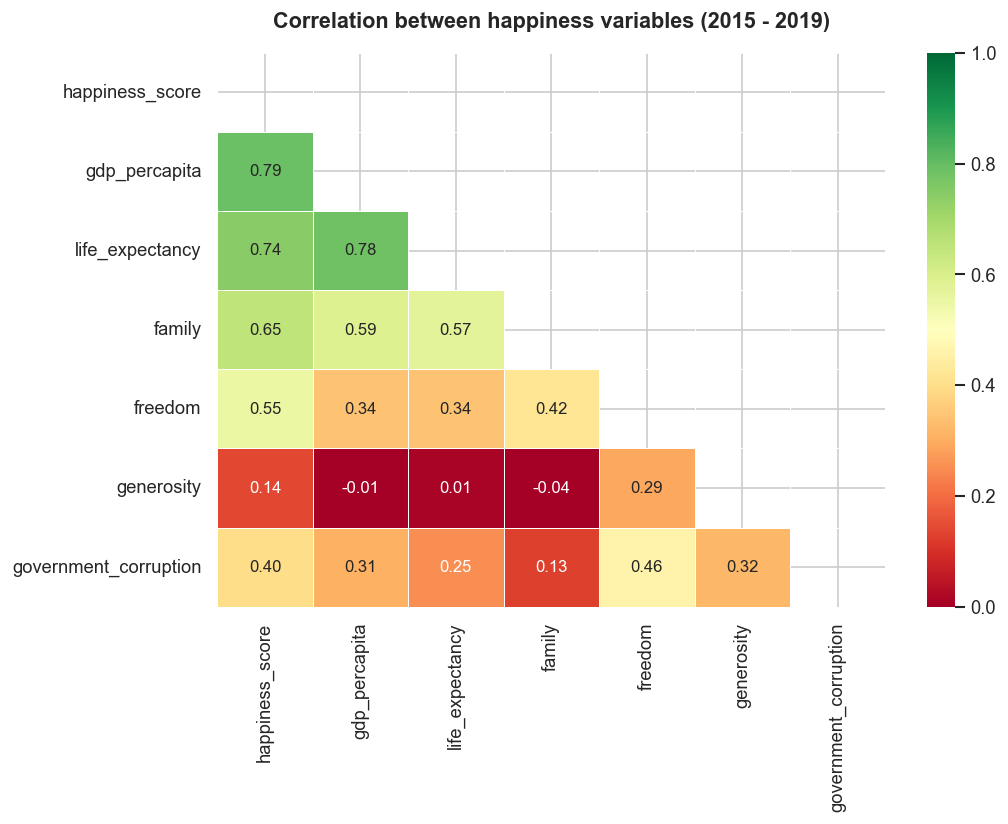

In [33]:
numeric_cols = ["happiness_score", "gdp_percapita", "life_expectancy",
                "family", "freedom", "generosity", "government_corruption"]

corr = hapy_country_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    linewidths=0.5, vmin=0, vmax=1, ax=ax,
    annot_kws={"size": 10}
)
ax.set_title("Correlation between happiness variables (2015 - 2019)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 2. GDP per capita vs Happiness Score

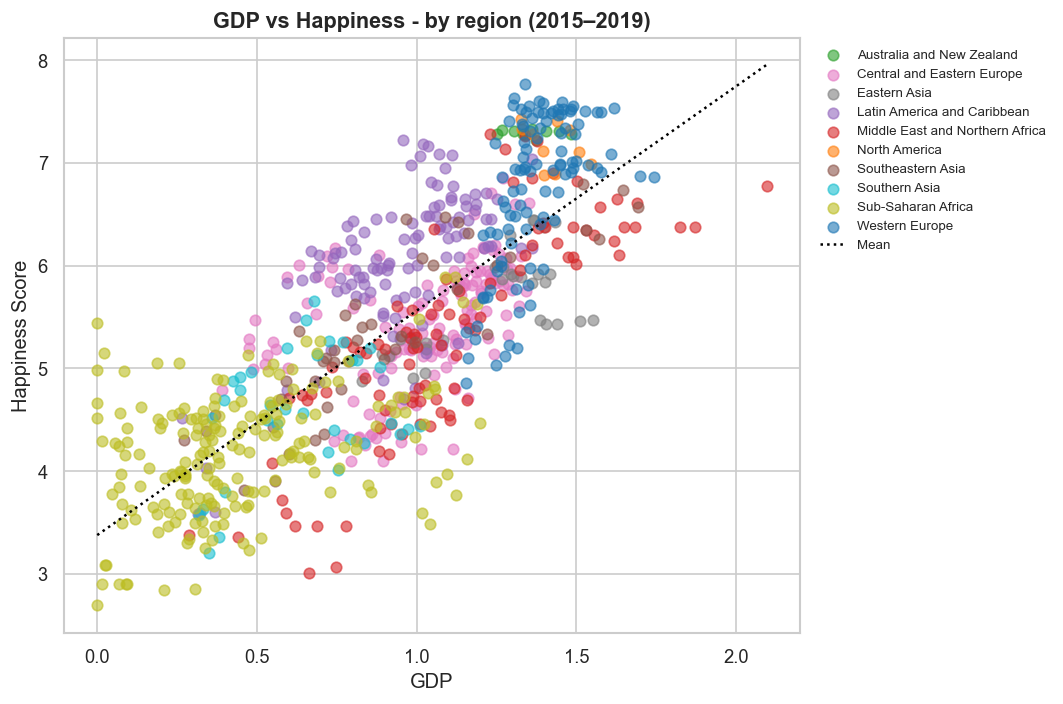

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))

regions = hapy_country_df["region"].unique()
palette = sns.color_palette("tab10", len(regions))
color_map = dict(zip(regions, palette))

for region, group in hapy_country_df.groupby("region"):
    ax.scatter(group["gdp_percapita"], group["happiness_score"],
               label=region, alpha=0.6, s=40, color=color_map[region])

m, b = np.polyfit(hapy_country_df["gdp_percapita"], hapy_country_df["happiness_score"], 1)
x_line = np.linspace(hapy_country_df["gdp_percapita"].min(), hapy_country_df["gdp_percapita"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="dotted", label="Mean")

ax.set_xlabel("GDP", fontsize=12)
ax.set_ylabel("Happiness Score", fontsize=12)
ax.set_title("GDP vs Happiness - by region (2015–2019)", fontsize=13, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## 3. Life Expectancy vs Happiness Score

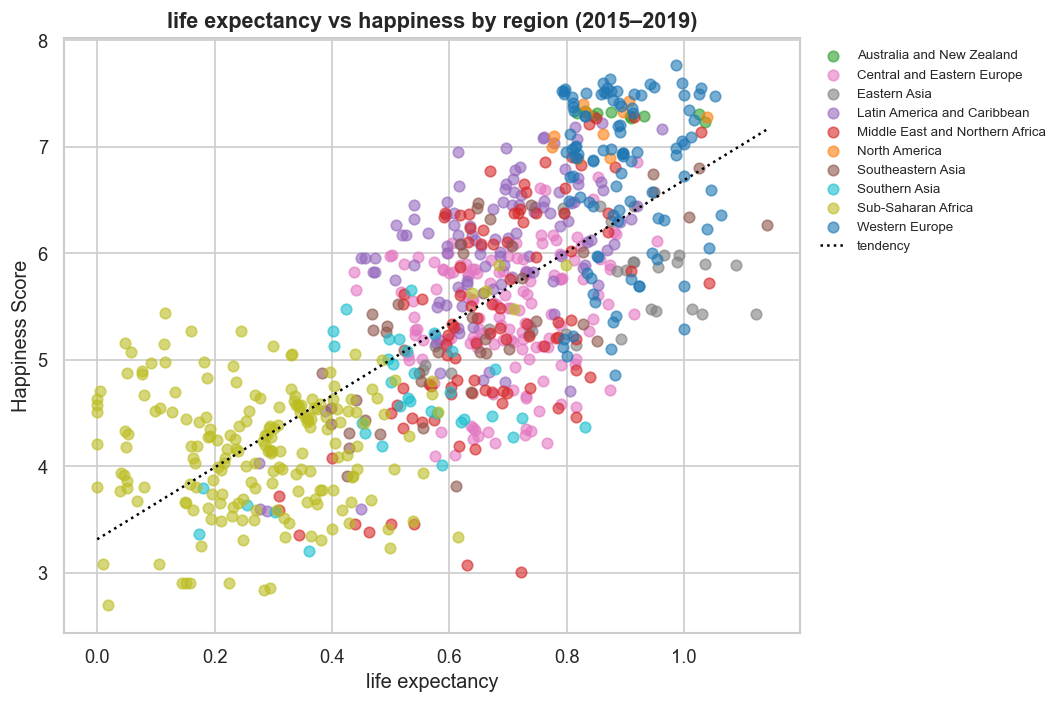

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))

for region, group in hapy_country_df.groupby("region"):
    ax.scatter(group["life_expectancy"], group["happiness_score"],
               label=region, alpha=0.6, s=40, color=color_map[region])

m, b = np.polyfit(hapy_country_df["life_expectancy"], hapy_country_df["happiness_score"], 1)
x_line = np.linspace(hapy_country_df["life_expectancy"].min(), hapy_country_df["life_expectancy"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="dotted", label="tendency")

ax.set_xlabel("life expectancy", fontsize=12)
ax.set_ylabel("Happiness Score", fontsize=12)
ax.set_title("life expectancy vs happiness by region (2015–2019)", fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## 4. Freedom vs Happiness Score

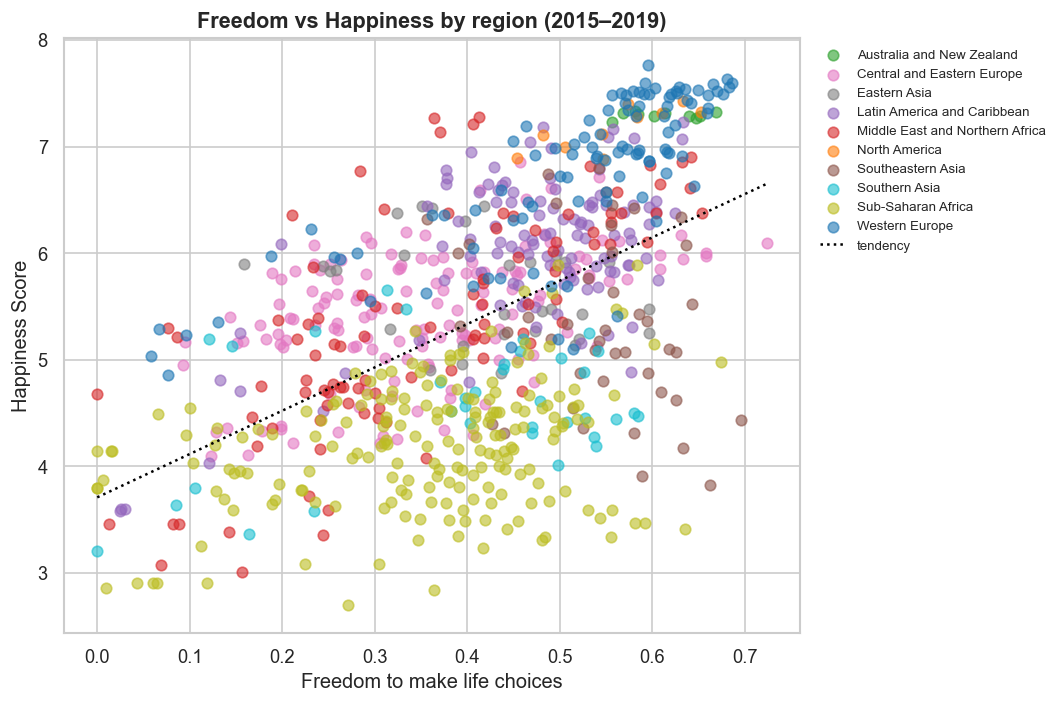

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

for region, group in hapy_country_df.groupby("region"):
    ax.scatter(group["freedom"], group["happiness_score"],
               label=region, alpha=0.6, s=40, color=color_map[region])

m, b = np.polyfit(hapy_country_df["freedom"], hapy_country_df["happiness_score"], 1)
x_line = np.linspace(hapy_country_df["freedom"].min(), hapy_country_df["freedom"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="dotted", label="tendency")

ax.set_xlabel("Freedom to make life choices", fontsize=12)
ax.set_ylabel("Happiness Score", fontsize=12)
ax.set_title("Freedom vs Happiness by region (2015–2019)", fontsize=13, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## 5.  Corruption vs Happiness

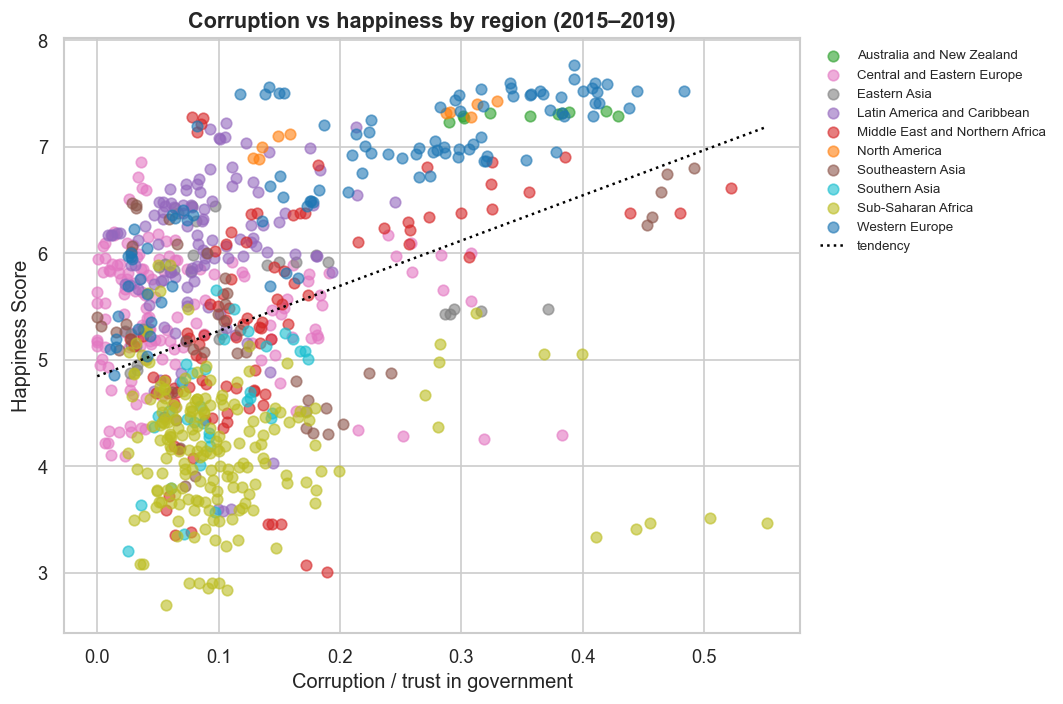

In [51]:
fig, ax = plt.subplots(figsize=(9, 6))

for region, group in hapy_country_df.groupby("region"):
    ax.scatter(group["government_corruption"], group["happiness_score"],
               label=region, alpha=0.6, s=40, color=color_map[region])

corruption_data = hapy_country_df["government_corruption"]
happiness_data = hapy_country_df["happiness_score"]

# Here I had to create a mask to filter out NaN values
mask = ~(np.isnan(corruption_data) | np.isnan(happiness_data) | 
         np.isinf(corruption_data) | np.isinf(happiness_data))

# Applied the mask to get clean data
clean_corruption = corruption_data[mask]
clean_happiness = happiness_data[mask]

if len(clean_corruption) > 1 and clean_corruption.std() > 0:
    m, b = np.polyfit(clean_corruption, clean_happiness, 1)
    x_line = np.linspace(clean_corruption.min(), clean_corruption.max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle="dotted", label='tendency')

ax.set_xlabel("Corruption / trust in government", fontsize=12)
ax.set_ylabel("Happiness Score", fontsize=12)
ax.set_title("Corruption vs happiness by region (2015–2019)", fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## 6. Happiness distribution by region

C:\Users\fotos\AppData\Local\Temp\ipykernel_25216\3916910376.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(region_avg['region'], rotation=35, ha='right', fontsize=9)


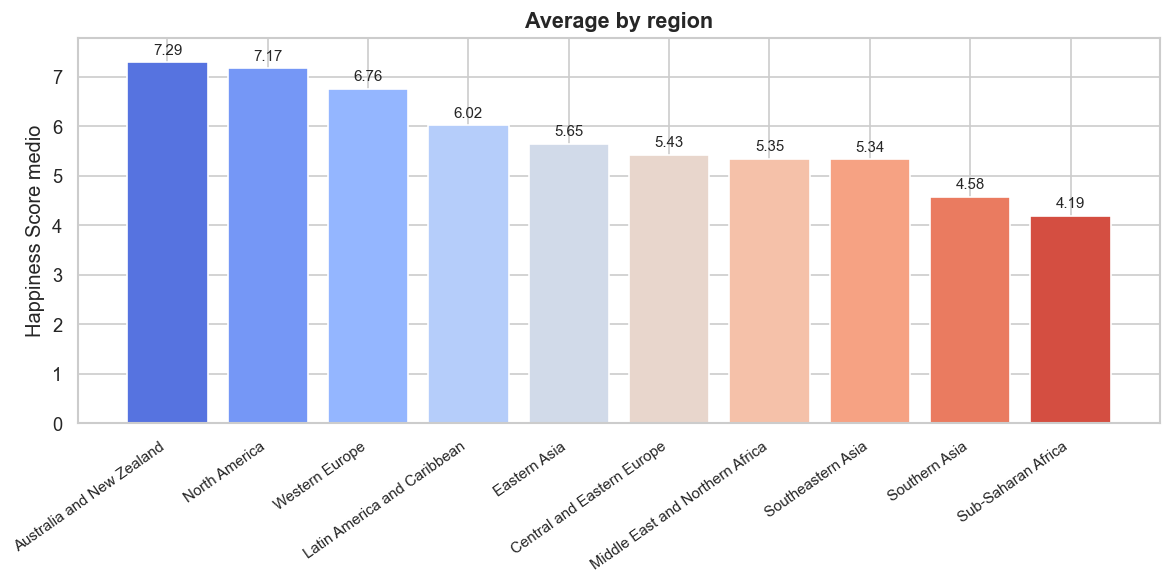

In [41]:
region_avg = (hapy_country_df.groupby('region')['happiness_score']
              .mean().sort_values(ascending=False).reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(region_avg['region'], region_avg['happiness_score'],
              color=sns.color_palette('coolwarm', len(region_avg)))
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xticklabels(region_avg['region'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Happiness Score medio', fontsize=12)
ax.set_title('Average by region', fontsize=13, fontweight='bold')
ax.set_ylim(0, region_avg['happiness_score'].max() + 0.5)
plt.tight_layout()
plt.show()

## 7. Happiness score evolution

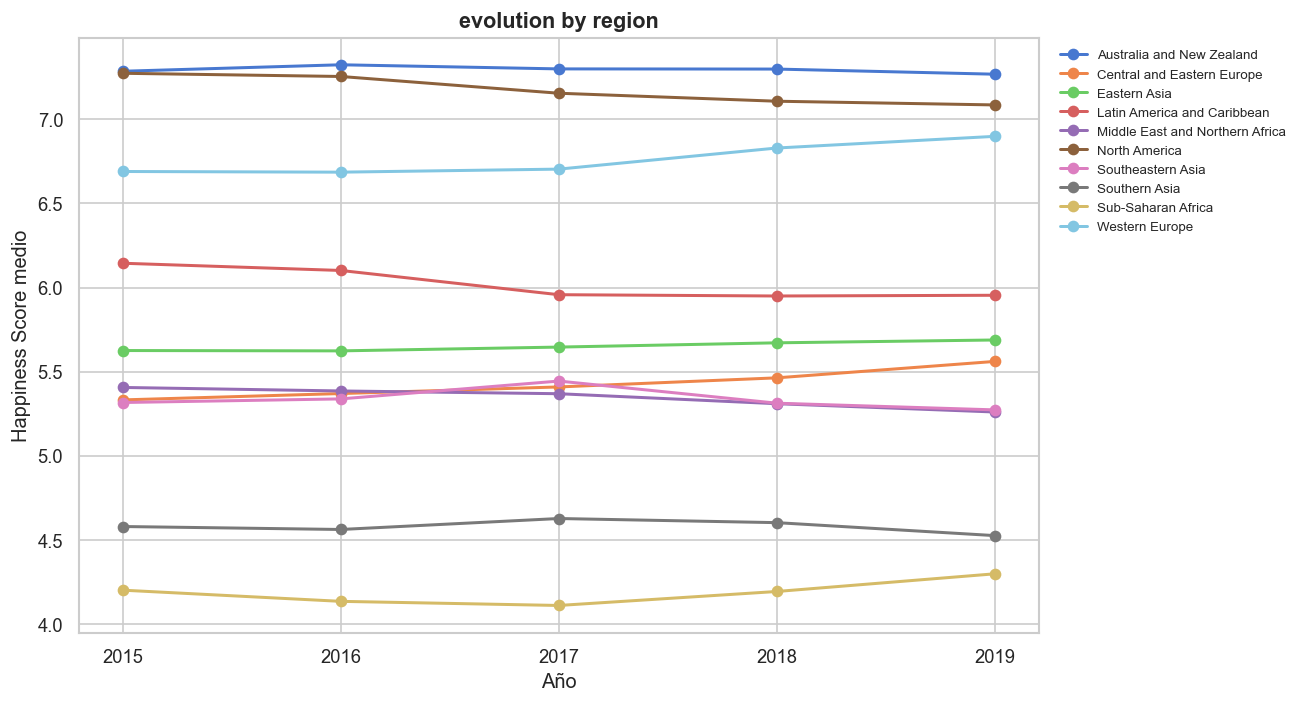

In [43]:
trend = (hapy_country_df.groupby(['year', 'region'])['happiness_score']
         .mean().reset_index())

fig, ax = plt.subplots(figsize=(11, 6))
for region, group in trend.groupby('region'):
    ax.plot(group['year'], group['happiness_score'],
            marker='o', label=region, linewidth=1.8)

ax.set_xticks([2015, 2016, 2017, 2018, 2019])
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Happiness Score medio', fontsize=12)
ax.set_title('evolution by region', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## TOP 10 happiest and saddest countries

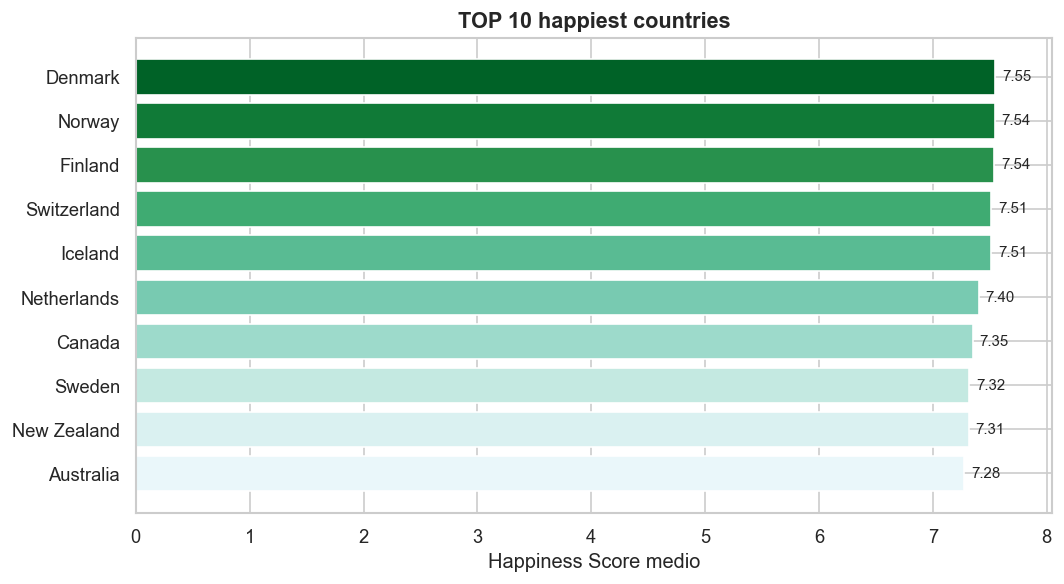

In [37]:
top10 = (hapy_country_df.groupby('country')['happiness_score']
         .mean().sort_values(ascending=False).head(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10['country'][::-1], top10['happiness_score'][::-1],
               color=sns.color_palette('BuGn', 10))
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
ax.set_xlabel('Happiness Score medio', fontsize=12)
ax.set_title('TOP 10 happiest countries', fontsize=13, fontweight='bold')
ax.set_xlim(0, top10['happiness_score'].max() + 0.5)
plt.tight_layout()
plt.show()

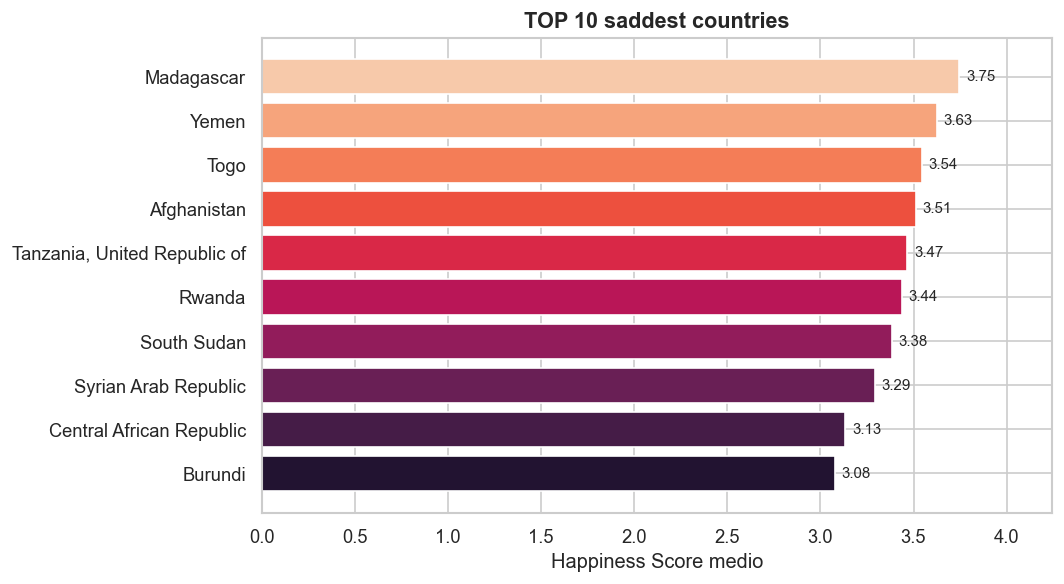

In [38]:
top10 = (hapy_country_df.groupby('country')['happiness_score']
         .mean().sort_values(ascending=False).tail(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10['country'][::-1], top10['happiness_score'][::-1],
               color=sns.color_palette('rocket', 10))
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
ax.set_xlabel('Happiness Score medio', fontsize=12)
ax.set_title('TOP 10 saddest countries', fontsize=13, fontweight='bold')
ax.set_xlim(0, top10['happiness_score'].max() + 0.5)
plt.tight_layout()
plt.show()